# Setup

In [ ]:
!pip install \
contextily==1.3.0 \
mapclassify==2.6.0 \
--upgrade --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 16.9 MB/s eta 0:00:00


In [ ]:
import numpy as np  # Library that provides functions for mathematical operations and handling arrays
import pandas as pd  # Library that provides a data frame class and functions to manipulate data frames
import geopandas as gpd  # Library that helps working with spatial data
import matplotlib.pyplot as plt  # Function for 2D plotting
import contextily as cx  # Library that helps adding OSM base layer to plots.
import plotly.express as px  # Library for interactive plotting

# Import data

In [ ]:
gdf  = gpd.read_file("https://github.com/quarcs-lab/data-quarcs/raw/refs/heads/master/indonesia514/gdfBeta.geojson")

In [ ]:
gdf.columns

Index(['districtID', 'district', 'distLongName', 'COORD_X', 'COORD_Y',
       'provinceID', 'province', 'islandID', 'island', 'region', 'regionID',
       'ln_gdppc2010', 'ln_gdppc2018', 'g', 'geometry'],
      dtype='object')

# Choroplet maps

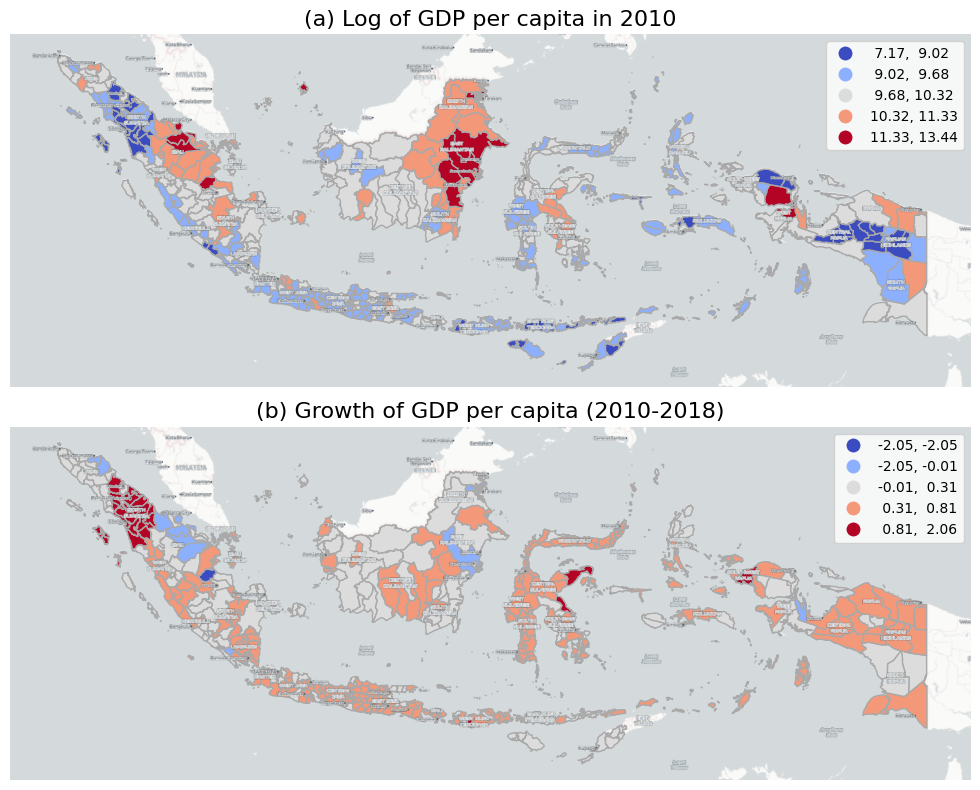

In [ ]:
##################################################################
# Application 2: Mapping the spatial distribution of initial GDP and growth
# URL: https://bit.ly/MGWRapp2
##################################################################

# 1. Initialize Figure and Subplots
# ---------------------------------
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

# 2. Define Function to Create Map
# --------------------------------
def create_map(ax, data, column, title):
    # Plot spatial data with FisherJenks classification
    data.plot(
        column=column,
        scheme="FisherJenks",
        cmap="coolwarm",
        edgecolor="darkgrey",
        legend=True,
        ax=ax,
    )

    # Add base layers for geographic context
    cx.add_basemap(
        ax=ax,
        crs=data.crs.to_string(),
        source=cx.providers.CartoDB.Positron,
        attribution=False,
    )
    cx.add_basemap(
        ax=ax,
        crs=data.crs.to_string(),
        source=cx.providers.CartoDB.PositronOnlyLabels,
        attribution=False,
    )

    # Customize subplot appearance
    ax.axis("off")
    ax.set_title(title, fontsize=16)

# 3. Create Maps for Each Variable
# -------------------------------
create_map(
    ax=axes[0],
    data=gdf,
    column="ln_gdppc2010",
    title="(a) Log of GDP per capita in 2010"
)

create_map(
    ax=axes[1],
    data=gdf,
    column="g",
    title="(b) Growth of GDP per capita (2010-2018)"
)

# 4. Optimize Layout and Save Figure
# ----------------------------------
plt.tight_layout()
plt.savefig("map_xy.png", dpi=150, bbox_inches="tight")
plt.show()